# CPT Taylor sweep: T2 vs T4 evolution across burst levels

For every post-finetune checkpoint in a results directory, run a short c=0 CPT (plain GD with `g_pre`) and record the two surviving Taylor terms at each step:

- $T_2 = -\eta\, g_{\mathrm{ft}}^\top g_{\mathrm{pre}}$ (first-order gradient-conflict forgetting)
- $T_4 = \tfrac{\eta^2}{2}\, g_{\mathrm{pre}}^\top H_{\mathrm{ft}}\, g_{\mathrm{pre}}$ (pure curvature damage)

Produces two plots per burst level (stacked and below each other): absolute magnitudes and summed-to-1 proportions.

In [1]:
import os, glob, json, importlib
os.chdir(".")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

import plot as plot_module
importlib.reload(plot_module)
from config import ExperimentConfig
from data import prepare_datasets, make_eval_loader

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [2]:
# ── Utility functions for gradient / curvature estimation ────────────────

def get_grad_vector(model, dataset, batch_size=16, num_batches=10):
    model.eval(); model.zero_grad()
    loader = make_eval_loader(dataset, batch_size)
    count = 0
    for i, batch in enumerate(loader):
        if i >= num_batches: break
        input_ids = batch.to(device)
        model(input_ids=input_ids, labels=input_ids).loss.backward()
        count += 1
    for p in model.parameters():
        if p.grad is not None:
            p.grad /= max(count, 1)
    grads = [p.grad.detach().flatten() for p in model.parameters() if p.grad is not None]
    model.zero_grad()
    return torch.cat(grads)

def eval_loss(model, dataset, batch_size=16, num_batches=10):
    model.eval()
    loader = make_eval_loader(dataset, batch_size)
    total, count = 0.0, 0
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= num_batches: break
            input_ids = batch.to(device)
            total += model(input_ids=input_ids, labels=input_ids).loss.item()
            count += 1
    return total / max(count, 1)

def get_flat_params(model):
    return torch.cat([p.detach().flatten() for p in model.parameters()])

def set_flat_params(model, flat):
    offset = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(flat[offset:offset+n].view_as(p))
        offset += n

def compute_kappa(model, direction, task_dataset, epsilon=1e-3,
                  batch_size=16, num_batches=10):
    """κ = direction^T H_task direction, central finite-diff HVP. `direction` unit-normed."""
    theta = get_flat_params(model)
    set_flat_params(model, theta + epsilon * direction)
    g_plus = get_grad_vector(model, task_dataset, batch_size, num_batches)
    set_flat_params(model, theta - epsilon * direction)
    g_minus = get_grad_vector(model, task_dataset, batch_size, num_batches)
    set_flat_params(model, theta)
    hvp = (g_plus - g_minus) / (2 * epsilon)
    return torch.dot(direction, hvp).item()

print("Utilities loaded.")

Utilities loaded.


In [3]:
# ── Knobs ──────────────────────────────────────────────────────────────
RESULTS_DIR = "results/20260424_195039_deep_70m_biomedical"
N_STEPS     = 10          # number of c=0 CPT steps to run for each burst level
BSZ         = 16          # batch size for grad / loss estimation
N_BATS      = 10          # batches per gradient / loss estimate
FD_EPS      = 1e-3        # finite-difference step for HVPs
# ──────────────────────────────────────────────────────────────────────

cfg = ExperimentConfig.from_json(os.path.join(RESULTS_DIR, "config.json"))
ETA = cfg.cpt_lr
print(f"RESULTS_DIR = {RESULTS_DIR}\nETA (cpt_lr) = {ETA}\nN_STEPS = {N_STEPS}")

RESULTS_DIR = results/20260424_195039_deep_70m_biomedical
ETA (cpt_lr) = 5e-05
N_STEPS = 10


In [4]:
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
datasets = prepare_datasets(cfg, tokenizer)
print("Datasets ready:", {k: len(v) for k, v in datasets.items()})

Datasets ready: {'domain_train': 601000, 'pile_train': 2522000, 'domain_valid': 2000, 'pile_valid': 2000}


In [5]:
N_STEPS     = 10          # number of c=0 CPT steps to run for each burst level


In [6]:
# ── Multi-step c=0 CPT + Taylor T2/T4 per step — 4-seed average ──
import torch.utils.data as tud

SEEDS = [42, 43, 44, 45]

ckpt_dirs = sorted(glob.glob(os.path.join(RESULTS_DIR, "models", "burst_*/post_finetune")))
seed_traces = {}  # (seed, burst_level) -> list[dict]

for seed_idx, SEED in enumerate(SEEDS):
    print(f"\n{'#'*60}")
    print(f"# SEED {SEED}  ({seed_idx+1}/{len(SEEDS)})")
    print(f"{'#'*60}")

    # Permute eval data so each seed sees different batches
    rng = torch.Generator().manual_seed(SEED)
    perm_d = torch.randperm(len(datasets["domain_valid"]), generator=rng).tolist()
    perm_p = torch.randperm(len(datasets["pile_valid"]),   generator=rng).tolist()
    dv = tud.Subset(datasets["domain_valid"], perm_d)
    pv = tud.Subset(datasets["pile_valid"],   perm_p)

    for ckpt in ckpt_dirs:
        tag = os.path.basename(os.path.dirname(ckpt)).replace("burst_", "")
        bl  = float(tag.replace("_", "."))
        print(f"\n{'─'*55}\nburst={bl:.0%}  seed={SEED}")

        try:
            m = AutoModelForCausalLM.from_pretrained(
                os.path.abspath(ckpt), torch_dtype=torch.float32).to(device)
        except Exception as e:
            print(f"  skip — {e}")
            continue
        m.eval()

        trace = []
        for step in range(N_STEPS + 1):
            g_ft  = get_grad_vector(m, dv, BSZ, N_BATS)
            g_pre = get_grad_vector(m, pv, BSZ, N_BATS)
            nft   = g_ft.norm().item()
            npre  = g_pre.norm().item()
            inner = torch.dot(g_ft, g_pre).item()
            cos_  = inner / (nft * npre + 1e-15)

            g_pre_hat = g_pre / (npre + 1e-15)
            kappa_domain = compute_kappa(m, g_pre_hat, dv,
                                         epsilon=FD_EPS, batch_size=BSZ, num_batches=N_BATS)

            T2 = -ETA * inner
            T4 =  0.5 * ETA**2 * npre**2 * kappa_domain
            L_ft = eval_loss(m, dv, BSZ, N_BATS)

            trace.append(dict(step=step, L_ft=L_ft,
                              norm_ft=nft, norm_pre=npre, cos_sim=cos_,
                              kappa_domain=kappa_domain,
                              T2=T2, T4=T4, pred_dL=T2 + T4))
            print(f"  step {step:2d}: L_ft={L_ft:.4f}  cos={cos_:+.3f}  "
                  f"T2={T2:+.2e}  T4={T4:+.2e}")

            if step < N_STEPS:
                theta = get_flat_params(m)
                set_flat_params(m, theta - ETA * g_pre)

        seed_traces[(SEED, bl)] = trace
        del m
        if device == "cuda":
            torch.cuda.empty_cache()

# ── Average across seeds ──
all_bursts = sorted({bl for (_, bl) in seed_traces})
step_traces = {}       # bl -> list[dict]  (mean — same name so plots work)
step_traces_std = {}   # bl -> list[dict]

for bl in all_bursts:
    per_seed = [seed_traces[(s, bl)] for s in SEEDS if (s, bl) in seed_traces]
    if not per_seed:
        continue
    keys = [k for k in per_seed[0][0] if k != "step"]
    mean_trace, std_trace = [], []
    for si in range(len(per_seed[0])):
        md = {"step": si}
        sd = {"step": si}
        for k in keys:
            vals = [run[si][k] for run in per_seed]
            md[k] = np.mean(vals)
            sd[k] = np.std(vals)
        mean_trace.append(md)
        std_trace.append(sd)
    step_traces[bl] = mean_trace
    step_traces_std[bl] = std_trace

print(f"\nTraces averaged over {len(SEEDS)} seeds for {len(step_traces)} burst levels.")


`torch_dtype` is deprecated! Use `dtype` instead!



############################################################
# SEED 42  (1/4)
############################################################

───────────────────────────────────────────────────────
burst=25%  seed=42


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  step  0: L_ft=2.9207  cos=-0.025  T2=+1.47e-06  T4=+4.12e-08
  step  1: L_ft=2.9207  cos=-0.027  T2=+1.59e-06  T4=+4.09e-08
  step  2: L_ft=2.9207  cos=-0.027  T2=+1.59e-06  T4=+3.94e-08
  step  3: L_ft=2.9207  cos=-0.028  T2=+1.65e-06  T4=+3.83e-08
  step  4: L_ft=2.9207  cos=-0.029  T2=+1.71e-06  T4=+3.68e-08
  step  5: L_ft=2.9207  cos=-0.031  T2=+1.79e-06  T4=+3.74e-08
  step  6: L_ft=2.9207  cos=-0.030  T2=+1.76e-06  T4=+3.54e-08
  step  7: L_ft=2.9207  cos=-0.032  T2=+1.87e-06  T4=+3.49e-08
  step  8: L_ft=2.9207  cos=-0.033  T2=+1.96e-06  T4=+3.43e-08
  step  9: L_ft=2.9207  cos=-0.034  T2=+1.97e-06  T4=+3.29e-08
  step 10: L_ft=2.9207  cos=-0.034  T2=+1.99e-06  T4=+3.32e-08

───────────────────────────────────────────────────────
burst=50%  seed=42


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

...

  step  0: L_ft=2.9115  cos=-0.038  T2=+2.87e-06  T4=+7.68e-08
  step  1: L_ft=2.9115  cos=-0.037  T2=+2.74e-06  T4=+7.93e-08
  step  2: L_ft=2.9115  cos=-0.039  T2=+2.87e-06  T4=+6.99e-08
  step  3: L_ft=2.9115  cos=-0.040  T2=+2.94e-06  T4=+7.49e-08
  step  4: L_ft=2.9115  cos=-0.044  T2=+3.21e-06  T4=+6.82e-08
  step  5: L_ft=2.9115  cos=-0.043  T2=+3.16e-06  T4=+6.79e-08
  step  6: L_ft=2.9115  cos=-0.047  T2=+3.43e-06  T4=+6.52e-08
  step  7: L_ft=2.9115  cos=-0.049  T2=+3.57e-06  T4=+6.73e-08
  step  8: L_ft=2.9115  cos=-0.050  T2=+3.69e-06  T4=+6.59e-08
  step  9: L_ft=2.9116  cos=-0.051  T2=+3.75e-06  T4=+6.49e-08
  step 10: L_ft=2.9116  cos=-0.052  T2=+3.81e-06  T4=+6.14e-08

───────────────────────────────────────────────────────
burst=90%  seed=45


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  step  0: L_ft=2.9126  cos=-0.035  T2=+3.20e-06  T4=+1.57e-07
  step  1: L_ft=2.9126  cos=-0.036  T2=+3.27e-06  T4=+1.51e-07
  step  2: L_ft=2.9126  cos=-0.040  T2=+3.60e-06  T4=+1.47e-07
  step  3: L_ft=2.9126  cos=-0.043  T2=+3.80e-06  T4=+1.46e-07
  step  4: L_ft=2.9126  cos=-0.048  T2=+4.24e-06  T4=+1.41e-07
  step  5: L_ft=2.9126  cos=-0.048  T2=+4.26e-06  T4=+1.41e-07
  step  6: L_ft=2.9126  cos=-0.050  T2=+4.42e-06  T4=+1.38e-07
  step  7: L_ft=2.9126  cos=-0.055  T2=+4.85e-06  T4=+1.38e-07
  step  8: L_ft=2.9126  cos=-0.057  T2=+5.07e-06  T4=+1.29e-07
  step  9: L_ft=2.9126  cos=-0.058  T2=+5.07e-06  T4=+1.32e-07
  step 10: L_ft=2.9126  cos=-0.057  T2=+5.01e-06  T4=+1.22e-07

───────────────────────────────────────────────────────
burst=100%  seed=45


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  step  0: L_ft=2.9142  cos=-0.051  T2=+9.56e-05  T4=+3.12e-04
  step  1: L_ft=2.9146  cos=-0.299  T2=+6.50e-04  T4=+2.54e-04
  step  2: L_ft=2.9155  cos=-0.369  T2=+1.05e-03  T4=+2.04e-04
  step  3: L_ft=2.9167  cos=-0.386  T2=+1.35e-03  T4=+1.70e-04
  step  4: L_ft=2.9182  cos=-0.384  T2=+1.57e-03  T4=+1.47e-04
  step  5: L_ft=2.9199  cos=-0.376  T2=+1.73e-03  T4=+1.23e-04
  step  6: L_ft=2.9218  cos=-0.369  T2=+1.85e-03  T4=+1.06e-04
  step  7: L_ft=2.9237  cos=-0.361  T2=+1.95e-03  T4=+9.41e-05
  step  8: L_ft=2.9258  cos=-0.352  T2=+2.01e-03  T4=+8.37e-05
  step  9: L_ft=2.9278  cos=-0.345  T2=+2.06e-03  T4=+7.30e-05
  step 10: L_ft=2.9300  cos=-0.338  T2=+2.09e-03  T4=+6.41e-05

Traces averaged over 4 seeds for 5 burst levels.


## Plots

Per burst level, two panels:
- **Left**: stacked absolute magnitudes of $|T_2|$ and $|T_4|$ per CPT step.
- **Right**: normalized proportions $|T_2|/(|T_2|+|T_4|)$ and $|T_4|/(|T_2|+|T_4|)$ (sums to 1).

Data is also pickled alongside the figure.

saved: results/20260424_195039_deep_70m_biomedical/figures/cpt_taylor_sweep.pdf
       results/20260424_195039_deep_70m_biomedical/figures/cpt_taylor_sweep.png
       results/20260424_195039_deep_70m_biomedical/figures/cpt_taylor_sweep.pkl


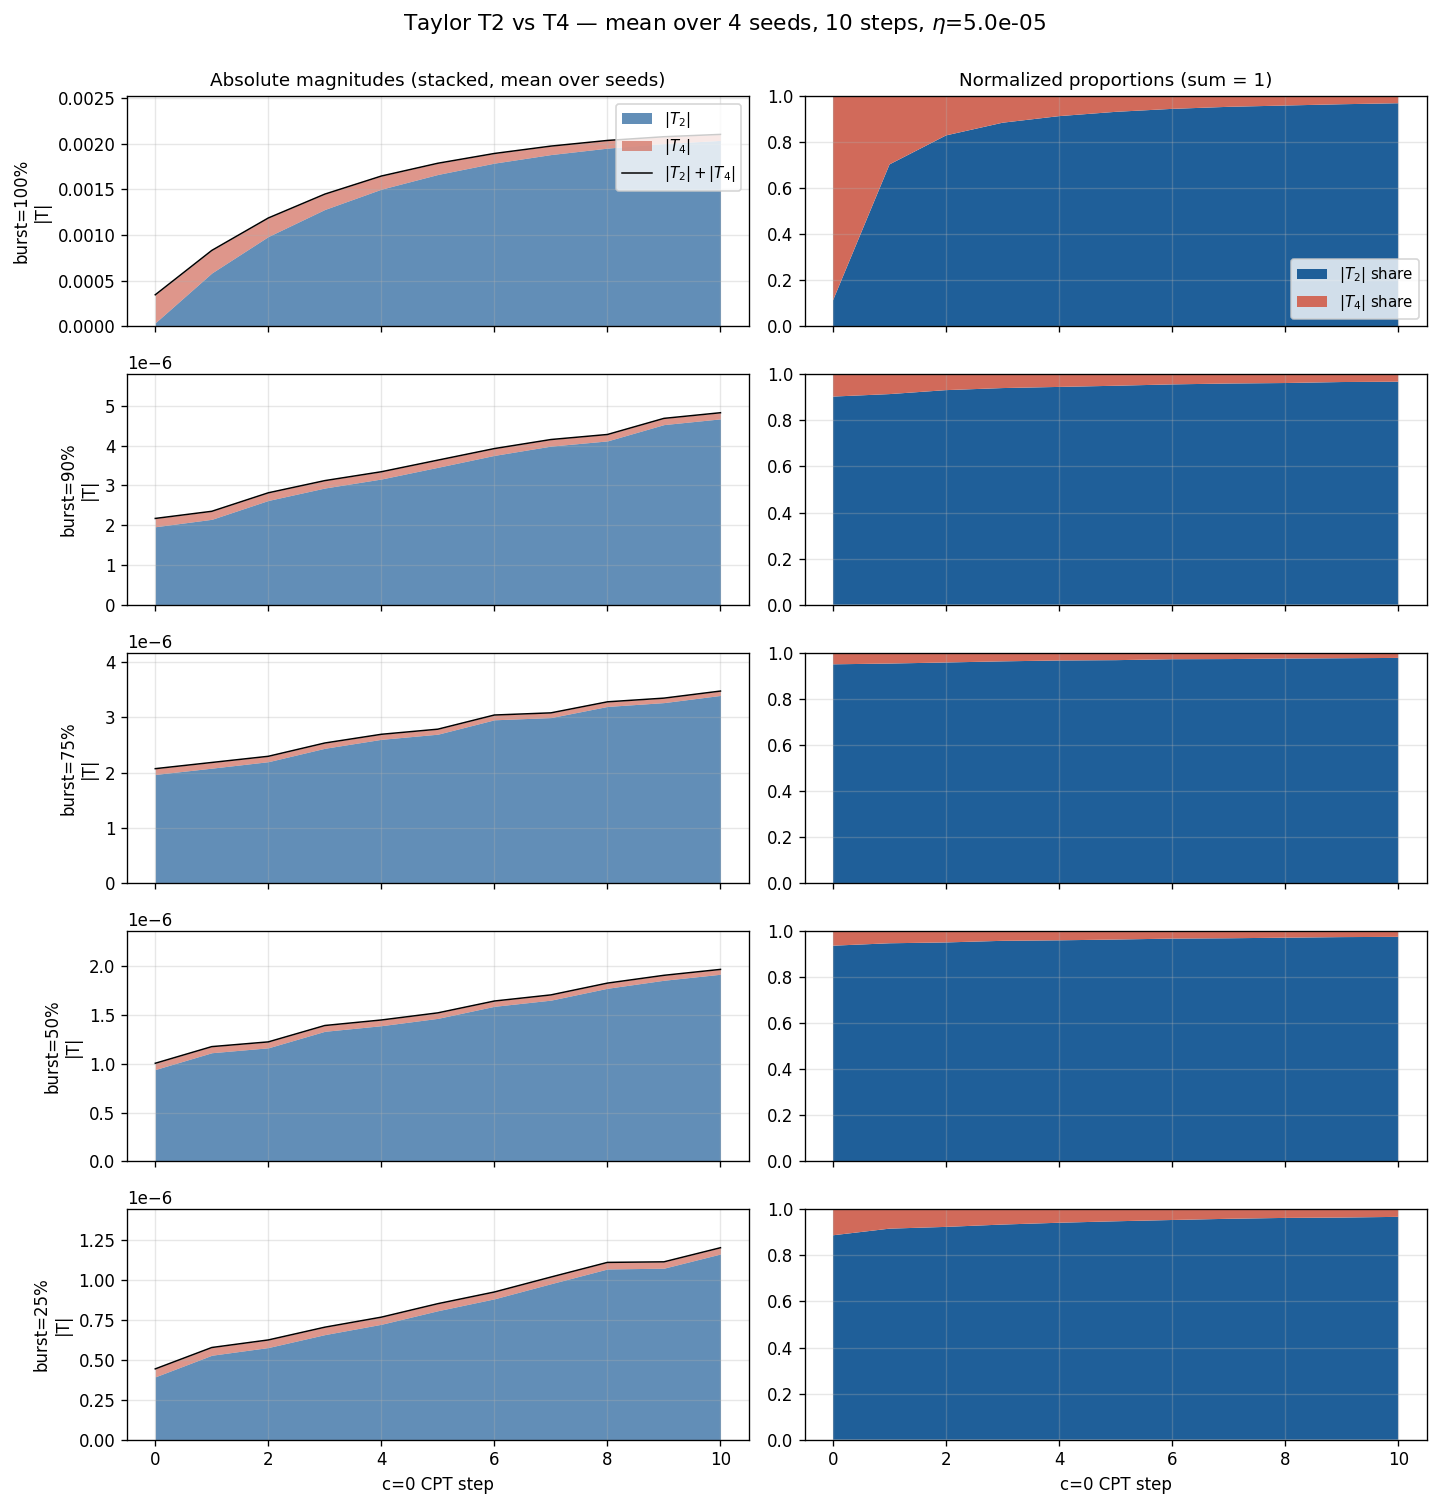

In [7]:
import pickle
from pathlib import Path

COL_T2 = "#1f5f99"   # first-order  (conflict)
COL_T4 = "#d16a5a"   # second-order (curvature)

bls_sorted = sorted(step_traces.keys(), reverse=True)
nrows = len(bls_sorted)

fig, axes = plt.subplots(nrows, 2, figsize=(12, 2.5 * nrows),
                         sharex=True, squeeze=False)

for i, bl in enumerate(bls_sorted):
    tr  = step_traces[bl]
    trs = step_traces_std[bl]
    steps = np.array([r["step"] for r in tr])
    aT2   = np.abs([r["T2"] for r in tr])
    aT4   = np.abs([r["T4"] for r in tr])
    sT2   = np.array([r["T2"] for r in trs])
    sT4   = np.array([r["T4"] for r in trs])
    tot   = aT2 + aT4
    safe  = np.where(tot > 0, tot, 1.0)
    fT2, fT4 = aT2 / safe, aT4 / safe

    # Left: absolute magnitudes, stacked + std shading
    ax = axes[i, 0]
    ax.fill_between(steps, 0,   aT2,        color=COL_T2, linewidth=0, alpha=0.7,
                    label=(r"$|T_2|$" if i == 0 else None))
    ax.fill_between(steps, aT2, aT2 + aT4,  color=COL_T4, linewidth=0, alpha=0.7,
                    label=(r"$|T_4|$" if i == 0 else None))
    ax.plot(steps, tot, "k-", lw=0.9,
            label=(r"$|T_2|+|T_4|$" if i == 0 else None))
    # Std bands on individual terms
    # ax.fill_between(steps, np.maximum(aT2 - sT2, 0), aT2 + sT2,
    #                 color=COL_T2, alpha=0.15)
    # ax.fill_between(steps, np.maximum(aT4 - sT4, 0), aT4 + sT4,
    #                 color=COL_T4, alpha=0.15)
    ax.set_ylabel(f"burst={bl:.0%}\n|T|", fontsize=10)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.set_title("Absolute magnitudes (stacked, mean over seeds)", fontsize=11)
        ax.legend(fontsize=9, loc="upper right")
    ax.set_ylim(0, max(tot) * 1.2)

    # Right: normalized proportions
    ax = axes[i, 1]
    ax.stackplot(steps, fT2, fT4, colors=[COL_T2, COL_T4],
                 labels=[r"$|T_2|$ share", r"$|T_4|$ share"])
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.set_title("Normalized proportions (sum = 1)", fontsize=11)
        ax.legend(fontsize=9, loc="lower right")

for ax in axes[-1]:
    ax.set_xlabel("c=0 CPT step")

fig.suptitle(f"Taylor T2 vs T4 — mean over {len(SEEDS)} seeds, "
             f"{N_STEPS} steps, $\\eta$={ETA:.1e}",
             fontsize=13, y=1.00)
fig.tight_layout()

# Save
out_dir = Path(RESULTS_DIR) / "figures"
out_dir.mkdir(parents=True, exist_ok=True)
fig_path = out_dir / "cpt_taylor_sweep"
fig.savefig(fig_path.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".png"), bbox_inches="tight", dpi=200)
with open(fig_path.with_suffix(".pkl"), "wb") as f:
    pickle.dump({"eta": ETA, "n_steps": N_STEPS, "seeds": SEEDS,
                 "traces_mean": step_traces, "traces_std": step_traces_std,
                 "seed_traces": seed_traces}, f)
print(f"saved: {fig_path.with_suffix('.pdf')}")
print(f"       {fig_path.with_suffix('.png')}")
print(f"       {fig_path.with_suffix('.pkl')}")
plt.show()


---
## Why does the curvature term grow with $c$? Three candidate mechanisms

The curvature-damage term $\tfrac{1}{2}\, g_{\mathrm{pre}}^\top H_{\mathrm{ft}}\, g_{\mathrm{pre}}$ has two ingredients that can each change with burst concentration $c$: the Hessian $H_{\mathrm{ft}}$ and the pre-train gradient $g_{\mathrm{pre}}$. Three possible explanations for why the quadratic form grows with $c$:

1. **Directional curvature.** $H_{\mathrm{ft}}$ is sharper *specifically* along $g_{\mathrm{pre}}$ at high $c$. The basin is narrow in the exact direction reversion pushes you.
2. **Isotropic sharpness.** $H_{\mathrm{ft}}$ is sharper *in all directions* at high $c$; $g_{\mathrm{pre}}$ just inherits that.
3. **Gradient magnitude.** $H_{\mathrm{ft}}$ is roughly unchanged, but $\|g_{\mathrm{pre}}\|$ grows with $c$, so the Hessian sandwich grows simply because the vector being plugged in is longer.

**Diagnostic.** Measure three quantities at the end of fine-tuning for each $c$:
- $\lambda_{\mathrm{dir}} = \dfrac{g_{\mathrm{pre}}^\top H_{\mathrm{ft}}\, g_{\mathrm{pre}}}{\|g_{\mathrm{pre}}\|^2}$ — Rayleigh quotient of $H_{\mathrm{ft}}$ along $g_{\mathrm{pre}}$ (the directional curvature).
- $\lambda_{\mathrm{iso}} = \mathrm{Tr}(H_{\mathrm{ft}}) / d$ — average curvature over *all* directions (via Hutchinson's estimator).
- $\|g_{\mathrm{pre}}\|^2$ — squared norm of the pre-train gradient.

**Reading the sweep over $c$:**
- $\lambda_{\mathrm{dir}}$ grows, $\lambda_{\mathrm{iso}}$ flat → **directional curvature** (mechanism 1, strongest story).
- $\lambda_{\mathrm{dir}}$ and $\lambda_{\mathrm{iso}}$ both grow → **isotropic sharpness** (mechanism 2, weaker story).
- $\lambda_{\mathrm{dir}}$ flat, $\|g_{\mathrm{pre}}\|^2$ grows → **gradient magnitude** (mechanism 3 — curvature framing is misleading).


In [8]:
# ── Hutchinson-trace estimator for Tr(H_ft) ─────────────────────────────
# Uses the same finite-difference HVP machinery as `compute_kappa`. Rademacher
# random vectors v ∈ {−1,+1}^d satisfy v^T v = d exactly, so
#     Tr(H) ≈ E[v^T H v] = d · E[v̂^T H v̂]
# where v̂ = v / ‖v‖. We draw `N_HUTCH` independent Rademacher vectors and
# compute κ(v̂_i) = v̂_i^T H_ft v̂_i with the existing `compute_kappa` routine.

N_HUTCH = 70          # number of Rademacher probes per checkpoint (bump for lower variance)
HUTCH_SEED = 0
FD_EPS = 5e-3

def hutchinson_trace(model, task_dataset,
                     n_samples=N_HUTCH, epsilon=FD_EPS,
                     batch_size=BSZ, num_batches=N_BATS, seed=HUTCH_SEED):
    """Return (trace_est, iso_sharpness = trace/d, d, kappas_list)."""
    d = sum(p.numel() for p in model.parameters() if p.requires_grad)
    gen = torch.Generator(device=device).manual_seed(seed)
    kappas = []
    for _ in range(n_samples):
        v = (torch.randint(0, 2, (d,), generator=gen, device=device).float() * 2 - 1)
        v_hat = v / v.norm()
        kappas.append(compute_kappa(model, v_hat, task_dataset,
                                    epsilon=epsilon,
                                    batch_size=batch_size,
                                    num_batches=num_batches))
    mean_kappa = float(np.mean(kappas))
    return d * mean_kappa, mean_kappa, d, kappas


# ── Compute diagnostic per burst level at post-FT checkpoint ────────────
#  λ_dir     = κ_domain  (already in step_traces[bl][0])
#  ‖g_pre‖²  = (norm_pre)²     (already there)
#  λ_iso     = Tr(H_ft)/d      (new — Hutchinson)

mech_rows = []
for ckpt in sorted(glob.glob(os.path.join(RESULTS_DIR, "models", "burst_*/post_finetune"))):
    tag = os.path.basename(os.path.dirname(ckpt)).replace("burst_", "")
    bl  = float(tag.replace("_", "."))
    if bl not in step_traces:
        continue

    print(f"\n{'─'*55}\nburst={bl:.0%}  [{ckpt}]")
    m = AutoModelForCausalLM.from_pretrained(
        os.path.abspath(ckpt), torch_dtype=torch.float32).to(device)
    m.eval()

    trace_est, iso_sharp, d, kappas = hutchinson_trace(m, datasets["domain_valid"])
    del m
    if device == "cuda":
        torch.cuda.empty_cache()

    s0       = step_traces[bl][0]
    lam_dir  = s0["kappa_domain"]           # ĝ_pre^T H_ft ĝ_pre
    g_pre_sq = s0["norm_pre"] ** 2
    quad     = g_pre_sq * lam_dir           # g_pre^T H_ft g_pre

    mech_rows.append(dict(
        burst        = bl,
        lam_dir      = lam_dir,
        lam_iso      = iso_sharp,
        g_pre_sq     = g_pre_sq,
        quad_form    = quad,
        trace_est    = trace_est,
        d            = d,
        hutch_kappas = kappas,
    ))
    print(f"  λ_dir = {lam_dir:.3f}   λ_iso = {iso_sharp:.3f}   "
          f"‖g_pre‖² = {g_pre_sq:.3e}   quad = {quad:.3e}   d = {d:,}")
    print(f"  Hutchinson κ samples: {['%.3f'%k for k in kappas]}")

mech_df = pd.DataFrame(mech_rows).sort_values("burst").reset_index(drop=True)
display(mech_df[["burst", "lam_dir", "lam_iso", "g_pre_sq", "quad_form", "trace_est", "d"]])



───────────────────────────────────────────────────────
burst=25%  [results/20260424_195039_deep_70m_biomedical/models/burst_0_25/post_finetune]


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  λ_dir = 33.683   λ_iso = 0.001   ‖g_pre‖² = 1.178e+00   quad = 3.967e+01   d = 70,426,624
  Hutchinson κ samples: ['0.001', '0.000', '0.000', '0.002', '0.001', '0.001', '0.002', '-0.001', '0.001', '0.001', '0.001', '0.000', '0.001', '0.001', '0.001', '-0.000', '0.002', '0.001', '0.001', '0.001', '0.001', '0.001', '0.001', '0.002', '0.003', '0.000', '0.000', '0.001', '-0.001', '-0.001', '0.002', '-0.000', '-0.001', '0.001', '-0.000', '0.001', '0.000', '-0.000', '0.002', '0.001', '0.001', '0.001', '0.001', '-0.000', '0.000', '0.001', '0.001', '0.002', '0.001', '0.000', '0.001', '0.001', '0.000', '0.001', '0.002', '0.002', '0.004', '-0.000', '0.000', '0.002', '0.002', '0.001', '0.000', '0.000', '0.001', '0.001', '0.001', '0.001', '0.001', '0.001']

───────────────────────────────────────────────────────
burst=50%  [results/20260424_195039_deep_70m_biomedical/models/burst_0_50/post_finetune]


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  λ_dir = 38.150   λ_iso = 0.001   ‖g_pre‖² = 1.347e+00   quad = 5.138e+01   d = 70,426,624
  Hutchinson κ samples: ['0.001', '0.001', '-0.001', '0.002', '-0.001', '0.001', '-0.000', '-0.001', '0.003', '-0.001', '-0.001', '0.002', '0.002', '0.001', '0.004', '0.001', '0.002', '-0.001', '-0.000', '0.004', '0.001', '-0.000', '-0.000', '0.003', '0.001', '0.001', '0.002', '0.000', '0.001', '0.003', '0.002', '0.000', '0.003', '0.001', '0.001', '0.000', '0.000', '0.001', '0.001', '0.001', '0.001', '0.001', '-0.001', '0.002', '0.005', '0.001', '0.000', '0.003', '0.001', '0.001', '-0.002', '-0.001', '0.002', '0.000', '-0.002', '0.000', '-0.000', '0.001', '0.000', '0.001', '-0.001', '0.000', '0.001', '-0.001', '0.003', '-0.000', '-0.001', '0.002', '0.000', '-0.002']

───────────────────────────────────────────────────────
burst=75%  [results/20260424_195039_deep_70m_biomedical/models/burst_0_75/post_finetune]


...

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  λ_dir = 78.385   λ_iso = 0.001   ‖g_pre‖² = 2.147e+00   quad = 1.683e+02   d = 70,426,624
  Hutchinson κ samples: ['-0.001', '-0.000', '0.006', '0.003', '-0.003', '0.001', '0.002', '-0.003', '0.002', '0.000', '-0.000', '0.003', '0.003', '0.002', '-0.002', '-0.001', '0.003', '0.000', '0.003', '0.000', '0.003', '-0.000', '0.003', '0.002', '0.001', '-0.000', '0.001', '-0.000', '0.001', '0.001', '0.004', '0.003', '0.003', '0.003', '0.003', '0.001', '0.004', '-0.001', '0.001', '0.002', '0.002', '0.002', '0.002', '0.001', '0.003', '-0.001', '0.003', '0.004', '0.000', '0.002', '0.002', '0.000', '0.001', '0.001', '0.002', '0.002', '0.001', '-0.003', '0.002', '0.003', '-0.001', '0.002', '0.001', '0.001', '0.004', '0.003', '0.004', '0.006', '-0.000', '0.001']

───────────────────────────────────────────────────────
burst=100%  [results/20260424_195039_deep_70m_biomedical/models/burst_1_00/post_finetune]


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  λ_dir = 387.814   λ_iso = 0.002   ‖g_pre‖² = 6.331e+02   quad = 2.455e+05   d = 70,426,624
  Hutchinson κ samples: ['0.001', '0.002', '0.002', '0.002', '0.003', '0.004', '-0.002', '0.002', '0.002', '0.005', '0.003', '0.001', '0.002', '0.004', '-0.002', '0.001', '0.004', '0.003', '0.008', '0.002', '0.006', '0.001', '-0.001', '0.003', '0.003', '-0.000', '-0.002', '0.002', '0.001', '0.001', '-0.001', '0.005', '0.003', '0.003', '-0.003', '0.002', '0.005', '0.003', '0.003', '0.001', '0.004', '0.002', '0.000', '0.004', '0.002', '0.001', '0.003', '0.002', '0.000', '0.001', '-0.001', '-0.001', '-0.001', '0.001', '0.002', '0.003', '0.003', '0.004', '0.000', '0.000', '0.005', '0.005', '0.004', '0.001', '0.004', '0.000', '0.002', '0.000', '-0.001', '0.005']


,burst,lam_dir,lam_iso,g_pre_sq,quad_form,trace_est,d
0,0.25,33.682567,0.000866,1.177785,39.670822,60956.748774,70426624
1,0.50,38.149661,0.000789,1.346870,51.382639,55593.144434,70426624
2,0.75,51.194879,0.001322,1.639028,83.909814,93126.563528,70426624
3,0.90,78.384943,0.001394,2.146517,168.254608,98153.140986,70426624
4,1.00,387.814423,0.001970,633.074614,245515.465866,138755.827918,70426624


saved: results/20260424_195039_deep_70m_biomedical/figures/curvature_mechanism.pdf
       results/20260424_195039_deep_70m_biomedical/figures/curvature_mechanism.png
       results/20260424_195039_deep_70m_biomedical/figures/curvature_mechanism.csv
       results/20260424_195039_deep_70m_biomedical/figures/curvature_mechanism.pkl


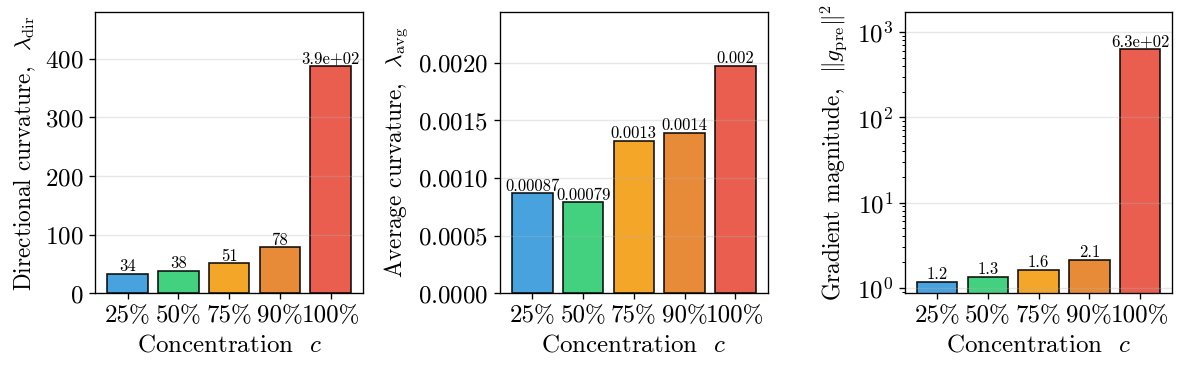


Relative change from lowest to highest c:
  λ_dir      : +1051.4%
  λ_iso      : +127.6%
  ‖g_pre‖²   : +53651.3%
  quad form  : +618781.7%


In [9]:
# ── Plot: three diagnostic quantities vs burst concentration c ──────────
bls_m       = mech_df["burst"].values
lam_dir_arr = mech_df["lam_dir"].values
lam_iso_arr = mech_df["lam_iso"].values
g_pre_sq    = mech_df["g_pre_sq"].values
quad_form   = mech_df["quad_form"].values

_LATEX_RC = {
    'font.family'       : 'serif',
    'font.serif'        : ['cmr10', 'DejaVu Serif'],
    'mathtext.fontset'  : 'cm',
    'axes.formatter.use_mathtext': True,
    'axes.unicode_minus': False,
    'font.size'         : 11,
}

with plt.rc_context(_LATEX_RC):
    colors_b = [plot_module.BURST_COLORS.get(bl, "gray") for bl in bls_m]

    fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))

    def _bars(ax, y, title, ylabel,scale='linear'):
        ax.bar(range(len(bls_m)), y, color=colors_b, edgecolor="black", alpha=0.9)
        ax.set_xticks(range(len(bls_m)))
        ax.set_xticklabels([f"{b:.0%}" for b in bls_m], fontsize = 15)
        ax.set_xlabel("Concentration  $c$", fontsize=15)
        ax.set_ylabel(title, fontsize = 14)
    #     ax.set_title(title, fontsize=11)
        ax.grid(axis="y", alpha=0.3)
        ax.set_yscale(scale)
        ax.tick_params(axis='both', labelsize=15)
        
            
        for i, v in enumerate(y):
            ax.text(i, v, f"{v:.2g}", ha="center",
                    va="bottom" if v >= 0 else "top", fontsize=10)
        # Headroom so value labels sit clearly inside the axes.
        ymin, ymax = ax.get_ylim()
        if scale == 'log':
            ax.set_ylim(ymin, ymax * 2.0)
        else:
            pad = (ymax - ymin) * 0.18
            ax.set_ylim(ymin, ymax + pad)


    _bars(axes[0], lam_dir_arr,
          r"Directional curvature,  $\lambda_{\mathrm{dir}}$",
          r"$\hat g_{\mathrm{pre}}^\top H_{\mathrm{ft}}\, \hat g_{\mathrm{pre}}$")
    _bars(axes[1], lam_iso_arr,
          r"Average curvature,  $\lambda_{\mathrm{avg}}$",
          r"$\mathrm{Tr}(H_{\mathrm{ft}})/d$  (Hutchinson)")
    _bars(axes[2], g_pre_sq,
          r"Gradient magnitude,  $\|g_{\mathrm{pre}}\|^2$",
          r"$\|g_{\mathrm{pre}}\|^2$", scale='log')

    # fig.suptitle("Mechanism diagnostic: what drives the curvature term's growth with $c$?",
    #              fontsize=13, y=1.02)
    fig.tight_layout()

    # Save figure + numbers
    out_dir  = Path(RESULTS_DIR) / "figures"
    out_dir.mkdir(parents=True, exist_ok=True)
    fig_path = out_dir / "curvature_mechanism"
    fig.savefig(fig_path.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(fig_path.with_suffix(".png"), bbox_inches="tight", dpi=200)
    mech_df.to_csv(fig_path.with_suffix(".csv"), index=False)
    with open(fig_path.with_suffix(".pkl"), "wb") as f:
        pickle.dump({"mech_df": mech_df.to_dict(orient="records"),
                     "n_hutch": N_HUTCH, "eta": ETA}, f)
    print(f"saved: {fig_path.with_suffix('.pdf')}")
    print(f"       {fig_path.with_suffix('.png')}")
    print(f"       {fig_path.with_suffix('.csv')}")
    print(f"       {fig_path.with_suffix('.pkl')}")
    plt.show()

# ── Plain-text verdict ──────────────────────────────────────────────────
def _rel_growth(y):
    y = np.asarray(y, dtype=float)
    lo, hi = y[0], y[-1]
    return (hi - lo) / (abs(lo) + 1e-30)

g_dir = _rel_growth(lam_dir_arr)
g_iso = _rel_growth(lam_iso_arr)
g_mag = _rel_growth(g_pre_sq)
print("\nRelative change from lowest to highest c:")
print(f"  λ_dir      : {g_dir:+.1%}")
print(f"  λ_iso      : {g_iso:+.1%}")
print(f"  ‖g_pre‖²   : {g_mag:+.1%}")
print(f"  quad form  : {_rel_growth(quad_form):+.1%}")
